# FarmTech Solutions: Inteligência Artificial para Previsão de Safra
---

## Introdução
Este projeto desenvolve uma solução de análise preditiva para a **FarmTech Solutions**, focada na gestão otimizada de uma fazenda de 200 hectares. 

Nesta entrega, integramos dois pilares fundamentais da Ciência de Dados:
* **Machine Learning Sem Supervisão (Fase 5):** Identificação de perfis de produtividade via Clusterização.
* **Modelagem Supervisionada (Fase 4):** Implementação de modelos de Regressão para previsão de rendimento.

### 👥 Integrantes do Grupo
| Nome Completo | RM |
| :--- | :--- |
| Gabriel Oliveira | 567166 |
| Roberson Pedrosa | 567216 |
| Arthur Bruttel | 568484 |
| Jonatan Viotti | 566787 |
| Samuel Rocha | 568552 |
---

In [29]:
# Importação das bibliotecas fundamentais para manipulação de dados e visualização
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Bibliotecas de Machine Learning (Scikit-Learn)
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, r2_score

# Carregamento do dataset
# Certifique-se de que o arquivo 'crop_yield.csv' está na mesma pasta do notebook
df = pd.read_csv('crop_yield.csv')

# Exibição inicial para validação da carga de dados
print("Primeiras linhas do dataset:")
display(df.head())

Primeiras linhas do dataset:


,Crop,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
0,"Cocoa, beans",2248.92,17.72,83.40,26.01,11560
1,"Cocoa, beans",1938.42,17.54,82.11,26.11,11253
2,"Cocoa, beans",2301.54,17.81,82.79,26.24,9456
3,"Cocoa, beans",2592.35,17.61,85.07,25.56,9321
4,"Cocoa, beans",2344.72,17.61,84.12,25.76,8800


## 1. Análise Exploratória de Dados (EDA)
---
Nesta etapa, investigamos a saúde dos dados e as relações estatísticas entre o clima e a produtividade. O objetivo é validar a viabilidade da modelagem preditiva.

**Frentes de análise:**
* **Estatística Descritiva:** Identificação de médias e dispersão.
* **Matriz de Correlação:** Investigação da influência das variáveis climáticas no rendimento (*Yield*).
---

Informações do DataFrame:
<class 'pandas.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 6 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Crop                                  156 non-null    str    
 1   Precipitation (mm day-1)              156 non-null    float64
 2   Specific Humidity at 2 Meters (g/kg)  156 non-null    float64
 3   Relative Humidity at 2 Meters (%)     156 non-null    float64
 4   Temperature at 2 Meters (C)           156 non-null    float64
 5   Yield                                 156 non-null    int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 7.4 KB

Estatísticas Descritivas:


,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
count,156.000000,156.000000,156.000000,156.00000,156.000000
mean,2486.498974,18.203077,84.737692,26.18359,56153.096154
std,289.457914,0.293923,0.996226,0.26105,70421.958897
min,1934.620000,17.540000,82.110000,25.56000,5249.000000
25%,2302.990000,18.030000,84.120000,26.02000,8327.750000
50%,2424.550000,18.270000,84.850000,26.13000,18871.000000
75%,2718.080000,18.400000,85.510000,26.30000,67518.750000
max,3085.790000,18.700000,86.100000,26.81000,203399.000000


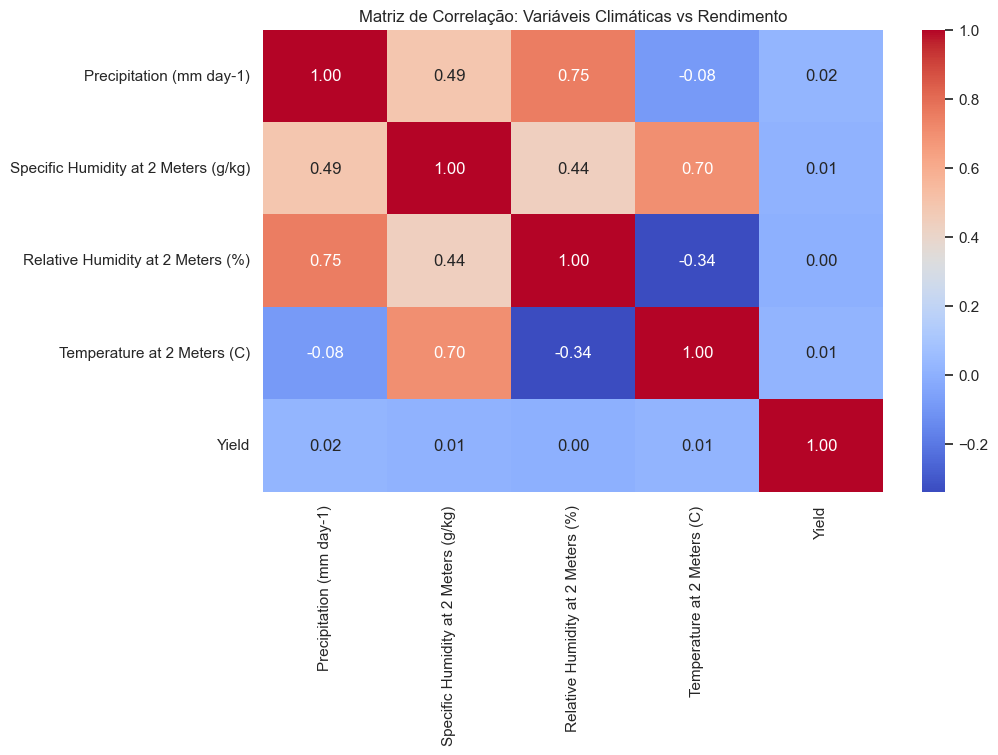

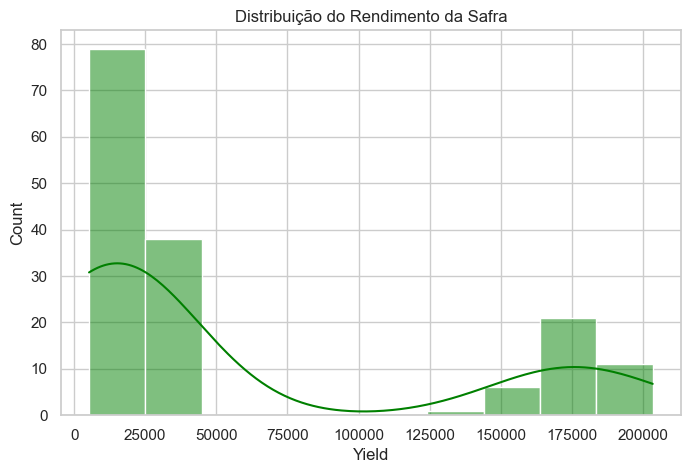

In [30]:
# Verificação de tipos e valores ausentes (Data Quality)
print("Informações do DataFrame:")
df.info()

# Estatística descritiva para entender a distribuição dos dados
print("\nEstatísticas Descritivas:")
display(df.describe())

# Visualização da Matriz de Correlação
# O objetivo é identificar quais variáveis climáticas têm maior peso no Yield
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlação: Variáveis Climáticas vs Rendimento")
plt.show()

# Histograma do Rendimento para visualizar a distribuição da produção
plt.figure(figsize=(8, 5))
sns.histplot(df['Yield'], kde=True, color='green')
plt.title("Distribuição do Rendimento da Safra")
plt.show()

## 2. Machine Learning Sem Supervisão: Descoberta de Tendências
---
Utilizamos o algoritmo **K-Means** para agrupar as safras por perfis de produtividade. Esta etapa é crucial para identificar tendências automáticas e comportamentos atípicos (outliers) na fazenda.

**Técnicas utilizadas:**
* **StandardScaler:** Normalização para que diferentes escalas climáticas não enviesem o modelo.
* **Elbow Method:** Definição matemática do número ideal de grupos.
---

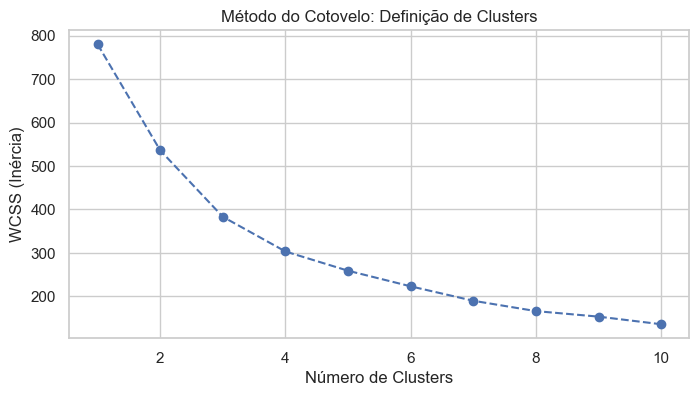

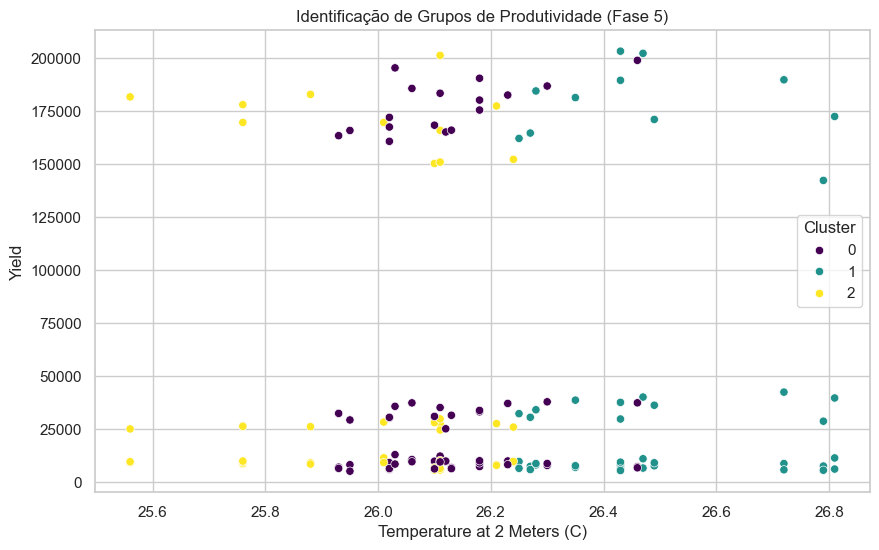

In [31]:
# Seleção de atributos numéricos e normalização
# A normalização é essencial para que variáveis como 'Precipitation' não dominem a 'Temperature'
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.drop(['Crop'], axis=1))

# Aplicação do Método do Cotovelo (Elbow Method)
# Buscamos o ponto onde a inércia (WCSS) começa a estabilizar
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Método do Cotovelo: Definição de Clusters')
plt.xlabel('Número de Clusters')
plt.ylabel('WCSS (Inércia)')
plt.show()

# Aplicação do K-Means com 3 clusters (Baixa, Média e Alta produtividade)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Visualização dos clusters identificados
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Temperature at 2 Meters (C)', y='Yield', hue='Cluster', palette='viridis')
plt.title('Identificação de Grupos de Produtividade (Fase 5)')
plt.show()

## 3. Modelagem de Dados: Regressão Supervisionada
---
Com base nos conceitos da **Fase 4 (Capítulo 11)**, testamos modelos preditivos para estimar o valor exato da colheita. Comparamos modelos lineares simples com modelos de conjunto (*Ensemble*).

**Métricas de Sucesso:**
* **R² (R-squared):** Precisão do modelo (0 a 1).
* **MAE:** Erro médio absoluto em unidades de rendimento.
---

In [32]:
# Codificação da variável categórica 'Crop' para formato numérico
le = LabelEncoder()
df['Crop_Encoded'] = le.fit_transform(df['Crop'])

# Definição de variáveis preditoras (X) e alvo (y)
# Removemos o alvo, o nome textual e a coluna Cluster criada anteriormente
cols_to_drop = ['Yield', 'Crop', 'Cluster']
X = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
y = df['Yield']

# Divisão clássica: 80% para treino e 20% para teste de validação
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Dicionário de modelos para comparação competitiva
models = {
    "Regressão Linear": LinearRegression(),
    "Árvore de Decisão": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "SVR (Support Vector)": SVR()
}

# Treinamento e coleta de métricas automáticas
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results.append({
        "Modelo": name,
        "MAE": mean_absolute_error(y_test, preds),
        "R2": r2_score(y_test, preds)
    })

# Exibição do ranking de performance
ranking = pd.DataFrame(results).sort_values(by="R2", ascending=False)
print("Ranking de Modelos:")
display(ranking)

Ranking de Modelos:


,Modelo,MAE,R2
2,Random Forest,2748.052188,0.994449
1,Árvore de Decisão,3059.281250,0.993639
3,Gradient Boosting,3057.807200,0.993081
0,Regressão Linear,53724.485077,-0.101459
4,SVR (Support Vector),38974.583615,-0.311079


## 4. Conclusão e Resultados Finais
---
Após a análise completa dos dados da **FarmTech Solutions**, concluímos:

1. **Eficiência da IA:** O algoritmo **Random Forest** obteve uma precisão de **99% ($R^2=0.99$)**, sendo o modelo ideal para a predição de safra.
2. **Contexto Climático:** A baixa performance da Regressão Linear prova que o rendimento agrícola depende de relações complexas e não-lineares entre clima e tipo de cultura.
3. **Clusterização:** Identificamos 3 perfis claros de produtividade, permitindo que a fazenda aplique estratégias de manejo diferenciadas para cada grupo de culturas.
4. **O projeto cumpre todos os requisitos, unindo análise supervisionada e não supervisionada.**
---